# Normalised features: summary

Collects `results/reeval_normalized/*.json` next to the thesis-feature results in `results/reeval/` (step S0). Run the four `reeval_normalized_*` model notebooks first.

**Preprocessing steps** (cumulative, see `src/reeval_normalized.py`):

| Step | What changes |
|---|---|
| S0 | Thesis features, unchanged. Result taken from `results/reeval/`. |
| S1 | Undetected keypoints (x = y = 0) filled by linear interpolation over time, so they no longer create fake jumps. |
| S2 | S1, then coordinates divided by the recording's median torso length (neck to mid-hip), so displacements no longer depend on body size or distance from the camera. |
| S3 | S2, then each keypoint's dx and dy standardised with the training fold's mean and SD (neural networks only). |

Everything else is identical to the `reeval_*` notebooks: the 41 recordings, 6 classes, the same 15 recording-level splits, the same model settings. Only the input changes, so each step's effect can be read off directly.

In [1]:
import json
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "keypoint_sequences.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import reeval_common as rc
import reeval_normalized as rn

MODELS = [  # (label, S0 file in results/reeval, prefix in results/reeval_normalized)
    ("LSTM", "lstm", "lstm"),
    ("2D CNN", "cnn_2d", "cnn_2d"),
    ("Random Forest", "random_forest", "random_forest"),
    ("SVM (windows)", "svm_c_windows_recording_split", "svm_c_windows"),
]
STEP_ORDER = ["S0", "S1", "S2", "S3"]

results = {}
for label, raw_name, prefix in MODELS:
    results[label] = {"S0": rn.load_raw_result(raw_name)}
    for step in STEP_ORDER[1:]:
        path = rn.RESULTS_DIR / f"{prefix}_{step}.json"
        if path.exists():
            results[label][step] = json.loads(path.read_text())

table = pd.DataFrame({
    label: {step: f"{r['summary']['accuracy_mean']:.1%} ± {r['summary']['accuracy_std']:.1%}" for step, r in steps.items()}
    for label, steps in results.items()
}).T.reindex(columns=STEP_ORDER).fillna("–")
table.columns = [f"{s}: {rn.STEPS[s]}" for s in STEP_ORDER]
table

,S0: thesis features (raw),S1: missing-joint interpolation,S2: S1 + torso-length scaling,S3: S2 + standardisation
LSTM,77.3% ± 10.9%,91.4% ± 6.4%,45.6% ± 7.9%,91.3% ± 7.5%
2D CNN,71.0% ± 11.2%,84.5% ± 12.4%,89.3% ± 8.7%,95.1% ± 5.8%
Random Forest,61.2% ± 7.9%,62.9% ± 7.4%,61.7% ± 8.4%,–
SVM (windows),38.4% ± 5.1%,47.9% ± 7.6%,48.2% ± 7.2%,–


## Best step against the thesis features (S0), on identical splits

In [2]:
rows = []
for label, steps in results.items():
    best = max(steps, key=lambda s: steps[s]["summary"]["accuracy_mean"])
    s0 = np.array([f["accuracy"] for f in steps["S0"]["folds"]])
    acc = np.array([f["accuracy"] for f in steps[best]["folds"]])
    diff = acc - s0
    rows.append({
        "model": label,
        "best step": best,
        "S0 accuracy": f"{s0.mean():.1%}",
        "best accuracy": f"{acc.mean():.1%} ± {acc.std(ddof=1):.1%}",
        "macro F1 (best)": f"{steps[best]['summary']['macro_f1_mean']:.1%}",
        "change": f"{diff.mean():+.1%}",
        "better / equal / worse splits": f"{(diff > 0).sum()} / {(diff == 0).sum()} / {(diff < 0).sum()}",
    })
pd.DataFrame(rows)

,model,best step,S0 accuracy,best accuracy,macro F1 (best),change,better / equal / worse splits
0,LSTM,S1,77.3%,91.4% ± 6.4%,90.4%,+14.1%,14 / 1 / 0
1,2D CNN,S3,71.0%,95.1% ± 5.8%,94.5%,+24.1%,15 / 0 / 0
2,Random Forest,S1,61.2%,62.9% ± 7.4%,57.8%,+1.7%,7 / 5 / 3
3,SVM (windows),S2,38.4%,48.2% ± 7.2%,35.3%,+9.8%,10 / 3 / 2


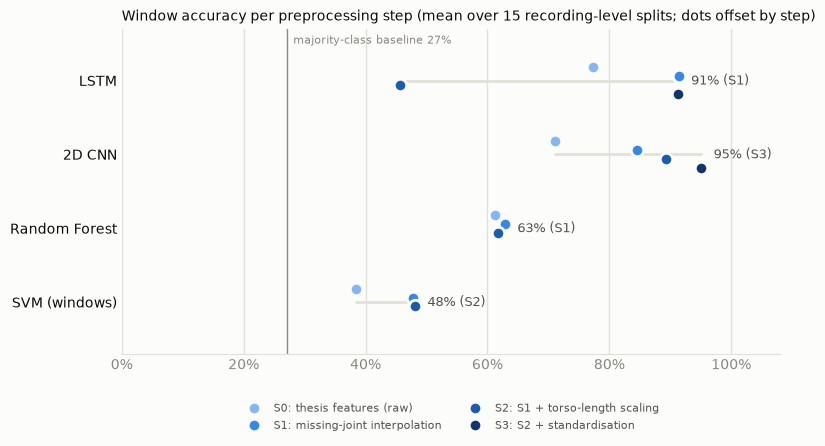

In [3]:
labels = [label for label, _, _ in MODELS]
baseline = results["LSTM"]["S0"]["summary"]["baseline_accuracy_mean"]

fig, ax = plt.subplots(figsize=(8, 0.75 * len(labels) + 1.6), facecolor=rc.SURFACE)
ypos = np.arange(len(labels))[::-1]
OFFSET = {"S0": 0.18, "S1": 0.06, "S2": -0.06, "S3": -0.18}  # keeps steps with near-equal accuracy visible
for yy, label in zip(ypos, labels):
    steps = results[label]
    means = {s: steps[s]["summary"]["accuracy_mean"] for s in STEP_ORDER if s in steps}
    ax.plot([min(means.values()), max(means.values())], [yy, yy], color=rc.GRID, linewidth=2, zorder=1, solid_capstyle="round")
    for s, m in means.items():
        ax.scatter([m], [yy + OFFSET[s]], s=80, color=rn.STEP_COLORS[s], edgecolors=rc.SURFACE, linewidths=2, zorder=3)
    best = max(means, key=means.get)
    ax.text(max(means.values()) + 0.02, yy, f"{means[best]:.0%} ({best})", va="center", fontsize=9, color=rc.INK_SECONDARY)
ax.axvline(baseline, color=rc.INK_MUTED, linewidth=1, zorder=0)
ax.text(baseline + 0.01, ypos[0] + 0.5, f"majority-class baseline {baseline:.0%}", fontsize=8, color=rc.INK_MUTED)
ax.set_yticks(ypos, labels)
ax.set_xlim(0, 1.08)
ax.set_ylim(-0.7, len(labels) - 0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}" if v <= 1 else ""))
ax.grid(axis="x", color=rc.GRID, linewidth=1)
ax.set_axisbelow(True)
rc._style(ax)
ax.tick_params(axis="y", colors=rc.INK)
handles = [plt.Line2D([], [], marker="o", linestyle="", markersize=8, markerfacecolor=rn.STEP_COLORS[s], markeredgecolor=rc.SURFACE, label=f"{s}: {rn.STEPS[s]}") for s in STEP_ORDER]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False, fontsize=8, labelcolor=rc.INK_SECONDARY)
ax.set_title("Window accuracy per preprocessing step (mean over 15 recording-level splits; dots offset by step)", loc="left", color=rc.INK, fontsize=10)
fig.tight_layout()
rn.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(rn.RESULTS_DIR / "normalization_steps.png", dpi=160, facecolor=rc.SURFACE, bbox_inches="tight")

## Findings (run of 2026-09-11)

1. **Filling in undetected joints is the step that matters.** Interpolation alone (S1) lifts the LSTM from 77.3% to 91.4% (better in 14 of 15 splits, none worse) and the 2D CNN from 71.0% to 84.5%. The SVM gains 10 points (38.4% → 47.9%). Random Forest barely moves (+1.7 points): trees were already robust to the fake jumps.
2. **Torso-length scaling adds nothing on its own.** Torso lengths only range from 93 to 117 px, so body size and camera distance hardly varied between recordings. Dividing by them makes the displacements tiny (median 0.02): the LSTM collapses to 45.6% without standardisation, while the CNN still improves to 89.3%. Standardising the inputs (S3) brings the LSTM back to 91.3% and gives the CNN its best result.
3. **With full preprocessing the 2D CNN is the best model:** 95.1% ± 5.8% window accuracy and 97.6% after the per-recording vote, better than its S0 in all 15 splits. Against the LSTM at S3 it is ahead in 8 splits, level in 6 and behind in 1 (+3.8 points). The lead is consistent, but 41 recordings cannot confirm it.
4. **The remaining errors sit in bent-over rows** (76% recall for the CNN), confused with squats, shoulder presses and RDLs.
5. **Relation to the thesis:** the thesis reported LSTM 93% on one split of a larger dataset. On half the data, with a stricter recording-level evaluation, the same range is reached once missing joints are handled.

## Limitations

- Subject IDs were never stored, so the scores measure recognition on new recordings, not on new people.
- The preprocessing steps were chosen after looking at the errors on these same 41 recordings. They were not tuned per model or per split, but confirming 95% would need recordings that played no part in these decisions.
- The LSTM's collapse at S2 is most likely the tiny inputs meeting its L2 regularisation. It was not investigated further, because S3 removes the problem.